# Clase 5 - Aprendizaje Supervisado
## Clasificación de tipos de vino utilizando K-NN y Árboles de Decisión

## Objetivo del proyecto

El objetivo de este trabajo es aplicar modelos de aprendizaje automático supervisado utilizando el dataset Wine. Se implementarán los algoritmos K-NN y Árboles de Decisión para clasificar distintos tipos de vino según sus características químicas.

Posteriormente se comparará el rendimiento de ambos modelos mediante métricas de evaluación y matrices de confusión.


### Importación de librerías y carga del dataset

In [2]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de machine learning
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Configuración visual
plt.style.use('ggplot')

# Nombres de columnas del dataset Wine
columnas = [
    "Clase", "Alcohol", "Malic_Acid", "Ash", "Alcalinity_of_Ash",
    "Magnesium", "Total_Phenols", "Flavanoids",
    "Nonflavanoid_Phenols", "Proanthocyanins",
    "Color_Intensity", "Hue", "OD280_OD315", "Proline"
]

# Carga del dataset
df = pd.read_csv("wine.csv", names=columnas)

# Mostrar primeras filas
print("Primeras filas del dataset Wine:")
df.head()

Primeras filas del dataset Wine:


,Clase,Alcohol,Malic_Acid,Ash,Alcalinity_of_Ash,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280_OD315,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


### Exploración inicial de los datos

In [4]:
# Dimensiones del dataset
print("Cantidad de filas y columnas:")
print(df.shape)

# Información general
print("\nInformación general del dataset:")
print(df.info())

# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
df.describe()

Cantidad de filas y columnas:
(178, 14)

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Clase                 178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic_Acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Alcalinity_of_Ash     178 non-null    float64
 5   Magnesium             178 non-null    int64  
 6   Total_Phenols         178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid_Phenols  178 non-null    float64
 9   Proanthocyanins       178 non-null    float64
 10  Color_Intensity       178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD280_OD315           178 non-null    float64
 13  Proline               178 non-null    int64  
dtype

,Clase,Alcohol,Malic_Acid,Ash,Alcalinity_of_Ash,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280_OD315,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


### Separación de variables y división de datos

In [6]:
# Variables predictoras
X = df.drop("Clase", axis=1)

# Variable objetivo
y = df["Clase"]

# División de datos en entrenamiento y prueba
X_entrenamiento, X_test, y_entrenamiento, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Mostrar dimensiones
print("Datos de entrenamiento:")
print(X_entrenamiento.shape)

print("\nDatos de prueba:")
print(X_test.shape)

Datos de entrenamiento:
(124, 13)

Datos de prueba:
(54, 13)


### Implementación del modelo K-NN

In [7]:
# Creación del modelo K-NN
modelo_knn = KNeighborsClassifier(n_neighbors=5)

# Entrenamiento del modelo
modelo_knn.fit(X_entrenamiento, y_entrenamiento)

# Predicciones
predicciones_knn = modelo_knn.predict(X_test)

# Precisión del modelo
precision_knn = accuracy_score(y_test, predicciones_knn)

print("Precisión del modelo K-NN:")
print(precision_knn)

Precisión del modelo K-NN:
0.7407407407407407


### Evaluación del modelo K-NN

In [8]:
# Matriz de confusión
matriz_knn = confusion_matrix(y_test, predicciones_knn)

print("Matriz de confusión - K-NN:")
print(matriz_knn)

# Reporte de clasificación
print("\nReporte de clasificación - K-NN:")
print(classification_report(y_test, predicciones_knn))

Matriz de confusión - K-NN:
[[17  0  2]
 [ 1 15  5]
 [ 1  5  8]]

Reporte de clasificación - K-NN:
              precision    recall  f1-score   support

           1       0.89      0.89      0.89        19
           2       0.75      0.71      0.73        21
           3       0.53      0.57      0.55        14

    accuracy                           0.74        54
   macro avg       0.73      0.73      0.73        54
weighted avg       0.74      0.74      0.74        54



### Matriz de confusión visual - K-NN

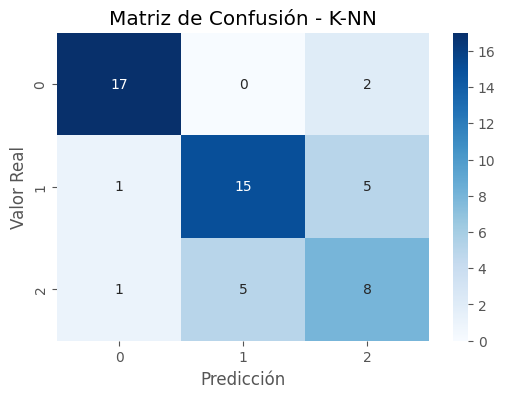

In [16]:
# Heatmap matriz de confusión K-NN
plt.figure(figsize=(6,4))

sns.heatmap(
    matriz_knn,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matriz de Confusión - K-NN")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

### Implementación del modelo Árbol de Decisión

In [9]:
# Creación del modelo Árbol de Decisión
modelo_arbol = DecisionTreeClassifier(max_depth=3, random_state=42)

# Entrenamiento del modelo
modelo_arbol.fit(X_entrenamiento, y_entrenamiento)

# Predicciones
predicciones_arbol = modelo_arbol.predict(X_test)

# Precisión del modelo
precision_arbol = accuracy_score(y_test, predicciones_arbol)

print("Precisión del modelo Árbol de Decisión:")
print(precision_arbol)

Precisión del modelo Árbol de Decisión:
0.9629629629629629


### Evaluación del modelo Árbol de Decisión

In [10]:
# Matriz de confusión
matriz_arbol = confusion_matrix(y_test, predicciones_arbol)

print("Matriz de confusión - Árbol de Decisión:")
print(matriz_arbol)

# Reporte de clasificación
print("\nReporte de clasificación - Árbol de Decisión:")
print(classification_report(y_test, predicciones_arbol))

Matriz de confusión - Árbol de Decisión:
[[18  1  0]
 [ 0 21  0]
 [ 0  1 13]]

Reporte de clasificación - Árbol de Decisión:
              precision    recall  f1-score   support

           1       1.00      0.95      0.97        19
           2       0.91      1.00      0.95        21
           3       1.00      0.93      0.96        14

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.97      0.96      0.96        54



### Matriz de confusión visual - Árbol de Decisión

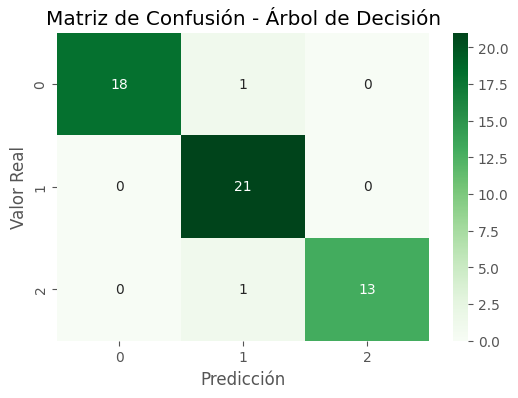

In [17]:
# Heatmap matriz de confusión Árbol de Decisión
plt.figure(figsize=(6,4))

sns.heatmap(
    matriz_arbol,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Matriz de Confusión - Árbol de Decisión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

### Comparación de modelos

In [13]:
# Comparación de precisión
print("Precisión K-NN:", precision_knn)
print("Precisión Árbol de Decisión:", precision_arbol)

Precisión K-NN: 0.7407407407407407
Precisión Árbol de Decisión: 0.9629629629629629


## Análisis de resultados

El modelo K-NN obtuvo una precisión aproximada del 74%, mientras que el modelo Árbol de Decisión alcanzó una precisión cercana al 96%.

Según los resultados obtenidos, el Árbol de Decisión presentó un mejor rendimiento para la clasificación de los tipos de vino del dataset Wine.

La matriz de confusión y las métricas de evaluación muestran que el Árbol de Decisión logró clasificar correctamente la mayoría de los registros, obteniendo valores altos de precisión, recall y f1-score.

### Visualización del Árbol de Decisión

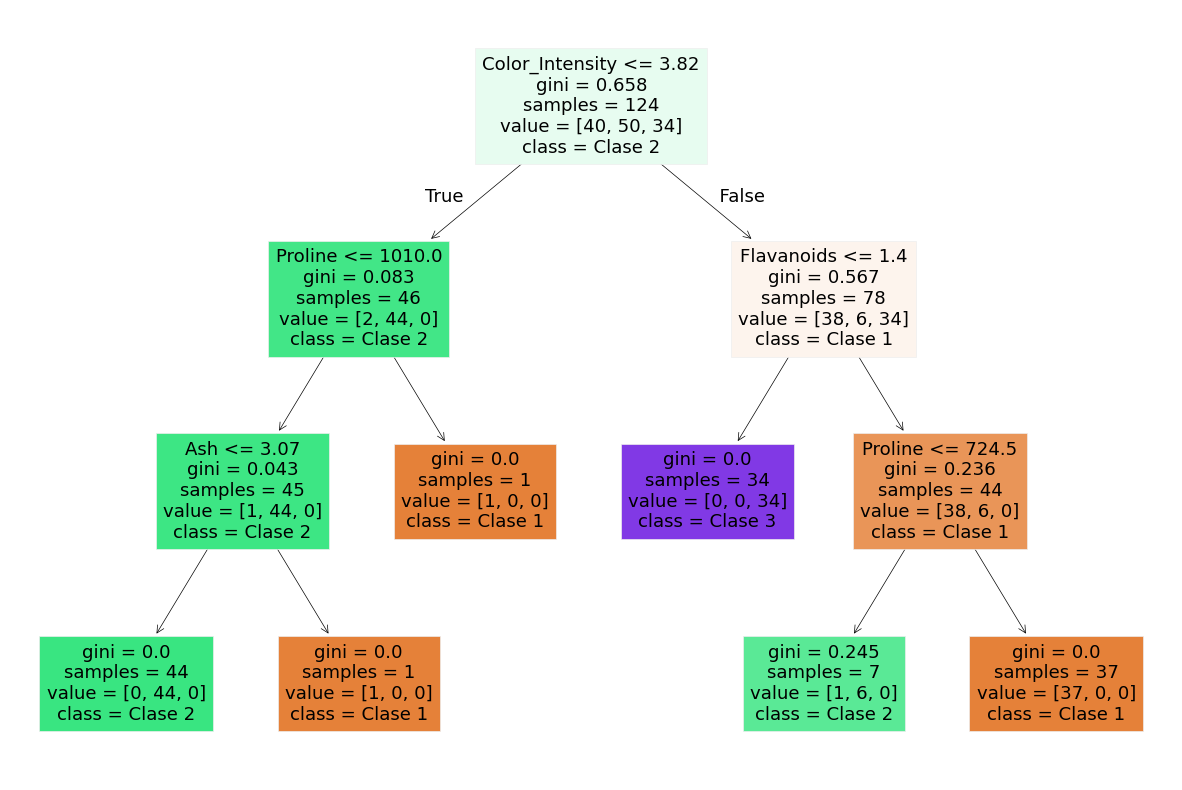

In [15]:
from sklearn import tree

# Tamaño de figura
plt.figure(figsize=(15,10))

# Graficar árbol
tree.plot_tree(
    modelo_arbol,
    feature_names=X.columns,
    class_names=["Clase 1", "Clase 2", "Clase 3"],
    filled=True
)

# Mostrar gráfico
plt.show()

### Conclusión final

En este trabajo se aplicaron modelos de aprendizaje automático supervisado utilizando el dataset Wine para clasificar distintos tipos de vino según sus características químicas.

Se implementaron los algoritmos K-NN y Árbol de Decisión, comparando posteriormente su rendimiento mediante métricas de evaluación y matrices de confusión.

Los resultados obtenidos muestran que el modelo Árbol de Decisión presentó un mejor desempeño, alcanzando una precisión aproximada del 96%, mientras que K-NN obtuvo una precisión cercana al 74%.

A partir del análisis realizado, se concluye que el modelo Árbol de Decisión fue más eficiente para este conjunto de datos, logrando una clasificación más precisa de los registros analizados.